# Track A — Notebook 1: LLaVA Inference + CHAIR Scoring
**CS 639 · UW–Madison · Spring 2026 · ViT Hallucination Research**

---

| Item | Detail |
|------|--------|
| **Goal** | Run LLaVA-1.5-7B on 500 COCO val images, score with CHAIR, export `chair_labels.csv` |
| **GPU** | **A100 (40 GB VRAM)** — full float16, no quantization |
| **Precision** | **float16** (~14 GB VRAM, full-precision attention weights) |
| **Runtime** | ~1–2 hours on A100 (checkpoints every 25 images) |
| **Output** | `chair_labels.csv` → **Track B handoff (Day 4)** |

### How to run
1. **Runtime → Change runtime type → A100 GPU → Save**
2. Run Cell 1 (installs packages)
3. **Runtime → Restart session** (mandatory after install)
4. Run Cells 2–10 top to bottom
5. If session disconnects: re-run Cells 2–7, then Cell 8 auto-resumes


## Cell 1 — Install Dependencies
> **After running this cell: Runtime → Restart session → skip to Cell 2**

In [ ]:
!pip install -q transformers==4.37.2 tokenizers==0.15.2 accelerate==0.27.2     pycocotools scipy Pillow tqdm pandas sentencepiece protobuf

import transformers, tokenizers
print(f"transformers: {transformers.__version__}")
print(f"tokenizers:   {tokenizers.__version__}")
print()
print("✅ Install complete.")
print("⚠️  NOW: Runtime → Restart session → then run Cell 2 (skip this cell)")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.37.2 which is incompatible.
transformers: 4.37.2
tokenizers:   0.15.2

✅ Install complete.
⚠️  NOW: Runtime → Restart session → then run Cell 2 (skip this cell)


## Cell 2 — Verify GPU + Mount Drive

In [ ]:
import subprocess, torch, sys

result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

if not torch.cuda.is_available():
    print("❌ No GPU. Go to: Runtime → Change runtime type → A100 GPU → Save")
    sys.exit(1)

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✅ GPU: {gpu_name} | VRAM: {vram_gb:.1f} GB")

if vram_gb < 30:
    print(f"⚠️  You have {vram_gb:.0f} GB VRAM. A100 should have 40+ GB.")
    print("   If you're on T4 (15 GB), float16 still fits but will be tighter.")

from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = "/content/drive/MyDrive/CS639_TrackA"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✅ Output directory: {OUTPUT_DIR}")


Sun Apr 19 16:59:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   30C    P0             48W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Cell 3 — Version Gate

In [ ]:
import transformers, tokenizers

tv = transformers.__version__
kv = tokenizers.__version__
print(f"transformers: {tv}")
print(f"tokenizers:   {kv}")

if tv != "4.37.2":
    print(f"\n❌ WRONG transformers version: {tv}")
    print("   Re-run Cell 1 → Runtime → Restart session → then come here")
    raise SystemExit("Version mismatch")
if kv != "0.15.2":
    print(f"\n❌ WRONG tokenizers version: {kv}")
    print("   Re-run Cell 1 → Runtime → Restart session → then come here")
    raise SystemExit("Version mismatch")

print("✅ Versions correct. Proceed.")


transformers: 4.37.2
tokenizers:   0.15.2
✅ Versions correct. Proceed.


## Cell 4 — Download COCO Val2017

In [ ]:
import os

COCO_DIR = "/content/coco"
IMG_DIR  = f"{COCO_DIR}/val2017"
ANN_FILE = f"{COCO_DIR}/annotations/instances_val2017.json"
os.makedirs(COCO_DIR, exist_ok=True)

if not os.path.exists(IMG_DIR):
    print("Downloading COCO val2017 images (~1 GB)...")
    !wget -q --show-progress http://images.cocodataset.org/zips/val2017.zip -P {COCO_DIR}
    !unzip -q {COCO_DIR}/val2017.zip -d {COCO_DIR}
    !rm -f {COCO_DIR}/val2017.zip
    print("✅ Images extracted.")
else:
    print("✅ Images already present.")

if not os.path.exists(ANN_FILE):
    print("Downloading annotations (~240 MB)...")
    !wget -q --show-progress http://images.cocodataset.org/annotations/annotations_trainval2017.zip -P {COCO_DIR}
    !unzip -q {COCO_DIR}/annotations_trainval2017.zip -d {COCO_DIR}
    !rm -f {COCO_DIR}/annotations_trainval2017.zip
    print("✅ Annotations extracted.")
else:
    print("✅ Annotations already present.")

n = len(os.listdir(IMG_DIR))
print(f"\nImages on disk: {n}")
assert n == 5000, f"Expected 5000, got {n}"


val2017.zip         100%[===================>] 777.80M  10.8MB/s    in 2m 32s  
✅ Images extracted.
annotations_trainva 100%[===================>] 241.19M  42.5MB/s    in 6.2s    
✅ Annotations extracted.

Images on disk: 5000


## Cell 5 — Load Annotations + Sample 500 Images

In [ ]:
from pycocotools.coco import COCO
import json, random

coco = COCO(ANN_FILE)
cat_id_to_name = {cat['id']: cat['name'] for cat in coco.dataset['categories']}

def get_gt_objects(image_id: int) -> set:
    ann_ids = coco.getAnnIds(imgIds=image_id)
    anns = coco.loadAnns(ann_ids)
    return set(cat_id_to_name[a['category_id']] for a in anns)

all_image_ids = coco.getImgIds()
random.seed(639)
SAMPLE_IDS = sorted(random.sample(all_image_ids, 500))

print(f"Total COCO val: {len(all_image_ids)}")
print(f"Sampled:        {len(SAMPLE_IDS)}")

with open(f"{OUTPUT_DIR}/sampled_image_ids.json", "w") as f:
    json.dump(SAMPLE_IDS, f)
print("✅ Saved sampled_image_ids.json")

sample_gt = get_gt_objects(SAMPLE_IDS[0])
print(f"\nSpot-check — Image {SAMPLE_IDS[0]}: {sample_gt}")


loading annotations into memory...
Done (t=0.69s)
creating index...
index created!
Total COCO val: 5000
Sampled:        500
✅ Saved sampled_image_ids.json

Spot-check — Image 776: {'bed', 'teddy bear'}


## Cell 6 — Load LLaVA-1.5-7B (float16 — Full Precision)

**A100 has 40 GB VRAM.** float16 model uses ~14 GB → 26 GB free for inference.

No quantization = full-precision attention weights = best data quality for Track A entropy analysis.

Uses **slow LlamaTokenizer** to bypass the Colab Python 3.12 fast-tokenizer crash.

In [ ]:
import torch
from transformers import (
    LlavaForConditionalGeneration,
    LlavaProcessor,
    CLIPImageProcessor,
    LlamaTokenizer,
)

MODEL_ID = "llava-hf/llava-1.5-7b-hf"

print(f"Loading {MODEL_ID} in float16 (NO quantization)...")
print(f"Available VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── float16 — full precision, no quantization ──
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)

# ── Slow tokenizer (fixes Colab Python 3.12 crash) ──
tokenizer = LlamaTokenizer.from_pretrained(MODEL_ID)
image_processor = CLIPImageProcessor.from_pretrained(MODEL_ID)
processor = LlavaProcessor(
    tokenizer=tokenizer,
    image_processor=image_processor,
)

model.eval()

vram_used  = torch.cuda.memory_allocated() / 1e9
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"\n✅ Model loaded (float16 — full precision).")
print(f"   VRAM used:     {vram_used:.2f} GB")
print(f"   VRAM total:    {vram_total:.1f} GB")
print(f"   VRAM free:     {vram_total - vram_used:.1f} GB")
print(f"   Utilization:   {vram_used/vram_total*100:.0f}%")


Loading llava-hf/llava-1.5-7b-hf in float16 (NO quantization)...
Available VRAM: 85.1 GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]


✅ Model loaded (float16 — full precision).
   VRAM used:     14.20 GB
   VRAM total:    85.1 GB
   VRAM free:     70.9 GB
   Utilization:   17%


## Cell 7 — CHAIR Scoring Functions

Matches all 80 COCO categories + common synonyms.

In [ ]:
import re

COCO_OBJECTS = {
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck',
    'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench',
    'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
    'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup',
    'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
    'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse',
    'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
    'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
}

SYNONYMS = {
    'man': 'person', 'woman': 'person', 'boy': 'person', 'girl': 'person',
    'child': 'person', 'kid': 'person', 'baby': 'person', 'guy': 'person',
    'people': 'person', 'player': 'person', 'rider': 'person', 'pedestrian': 'person',
    'skier': 'person', 'snowboarder': 'person', 'surfer': 'person', 'lady': 'person',
    'gentleman': 'person', 'individual': 'person',
    'bike': 'bicycle', 'cycle': 'bicycle',
    'automobile': 'car', 'vehicle': 'car', 'sedan': 'car', 'suv': 'car',
    'motorbike': 'motorcycle',
    'plane': 'airplane', 'aircraft': 'airplane', 'jet': 'airplane',
    'ship': 'boat', 'vessel': 'boat', 'sailboat': 'boat', 'yacht': 'boat',
    'stoplight': 'traffic light', 'signal light': 'traffic light',
    'hydrant': 'fire hydrant',
    'sofa': 'couch', 'loveseat': 'couch',
    'television': 'tv', 'monitor': 'tv', 'screen': 'tv',
    'notebook computer': 'laptop', 'computer': 'laptop',
    'phone': 'cell phone', 'mobile': 'cell phone', 'smartphone': 'cell phone',
    'cellphone': 'cell phone', 'mobile phone': 'cell phone',
    'fridge': 'refrigerator', 'icebox': 'refrigerator',
    'table': 'dining table', 'desk': 'dining table', 'counter': 'dining table',
    'countertop': 'dining table',
    'plant': 'potted plant', 'houseplant': 'potted plant', 'flower': 'potted plant',
    'flower pot': 'potted plant',
    'teddy': 'teddy bear',
    'doughnut': 'donut',
    'hotdog': 'hot dog',
    'racquet': 'tennis racket', 'racket': 'tennis racket',
    'purse': 'handbag', 'clutch': 'handbag',
    'bag': 'backpack', 'rucksack': 'backpack',
    'mug': 'cup', 'coffee cup': 'cup',
    'glass': 'wine glass', 'goblet': 'wine glass',
    'stove': 'oven',
    'dryer': 'hair drier', 'hair dryer': 'hair drier',
    'ball': 'sports ball', 'baseball': 'sports ball', 'basketball': 'sports ball',
    'football': 'sports ball', 'soccer ball': 'sports ball', 'tennis ball': 'sports ball',
    'bat': 'baseball bat',
    'glove': 'baseball glove', 'mitt': 'baseball glove',
    'ski': 'skis',
    'disc': 'frisbee',
    'parasol': 'umbrella',
    'necktie': 'tie', 'bowtie': 'tie',
    'luggage': 'suitcase', 'briefcase': 'suitcase',
}

def extract_mentioned_objects(caption: str) -> set:
    caption_lower = caption.lower()
    mentioned = set()
    for obj in COCO_OBJECTS:
        if re.search(r'\b' + re.escape(obj) + r'\b', caption_lower):
            mentioned.add(obj)
    for synonym, coco_cat in SYNONYMS.items():
        if re.search(r'\b' + re.escape(synonym) + r'\b', caption_lower):
            mentioned.add(coco_cat)
    return mentioned

def compute_chair(caption: str, gt_objects: set) -> dict:
    mentioned = extract_mentioned_objects(caption)
    if len(mentioned) == 0:
        return {'chair_i': 0.0, 'is_hallucinating': False,
                'mentioned': set(), 'hallucinated': set(),
                'n_mentioned': 0, 'n_hallucinated': 0}
    hallucinated = mentioned - gt_objects
    chair_i = len(hallucinated) / len(mentioned)
    return {'chair_i': chair_i, 'is_hallucinating': len(hallucinated) > 0,
            'mentioned': mentioned, 'hallucinated': hallucinated,
            'n_mentioned': len(mentioned), 'n_hallucinated': len(hallucinated)}

# Sanity test
test = compute_chair("A dog on a couch next to a cat", {"dog", "couch"})
print(f"Test — mentioned: {test['mentioned']}, halluc: {test['hallucinated']}, CHAIR_i: {test['chair_i']:.3f}")
print("✅ CHAIR functions ready.")


Test — mentioned: {'cat', 'couch', 'dog'}, halluc: {'cat'}, CHAIR_i: 0.333
✅ CHAIR functions ready.


## Cell 8 — Main Inference Loop (500 Images)

**~1–2 hours on A100.** Checkpoints every 25 images.

If session disconnects → re-run Cells 2–7 → re-run this cell (auto-resumes).

In [ ]:
import pandas as pd
import os, gc
from PIL import Image
from tqdm import tqdm

CHECKPOINT_PATH = f"{OUTPUT_DIR}/chair_checkpoint.csv"
FINAL_PATH      = f"{OUTPUT_DIR}/chair_labels.csv"

PROMPT = "USER: <image>\nDescribe everything you see in this image in detail, listing all objects, people, and animals visible.\nASSISTANT:"

# ── Resume from checkpoint ──
if os.path.exists(CHECKPOINT_PATH):
    existing_df = pd.read_csv(CHECKPOINT_PATH)
    results = existing_df.to_dict('records')
    done_ids = set(existing_df['image_id'].tolist())
    print(f"🔄 Resuming: {len(done_ids)}/500 done.")
else:
    results = []
    done_ids = set()
    print("🆕 Starting fresh.")

remaining = [i for i in SAMPLE_IDS if i not in done_ids]
print(f"   Remaining: {len(remaining)} images\n")

for idx, image_id in enumerate(tqdm(remaining, desc="LLaVA Inference")):
    try:
        img_info = coco.loadImgs(image_id)[0]
        img_path = f"{IMG_DIR}/{img_info['file_name']}"
        image = Image.open(img_path).convert("RGB")
        gt_objects = get_gt_objects(image_id)

        inputs = processor(text=PROMPT, images=image, return_tensors="pt")
        inputs = {k: v.to(model.device) if hasattr(v, 'to') else v
                  for k, v in inputs.items()}

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=150,
                do_sample=False,
            )

        input_len = inputs['input_ids'].shape[1]
        caption = processor.decode(
            output_ids[0][input_len:], skip_special_tokens=True
        ).strip()

        chair = compute_chair(caption, gt_objects)
        results.append({
            'image_id':            image_id,
            'file_name':           img_info['file_name'],
            'caption':             caption,
            'chair_i':             round(chair['chair_i'], 4),
            'is_hallucinating':    chair['is_hallucinating'],
            'gt_objects':          '|'.join(sorted(gt_objects)),
            'mentioned_objects':   '|'.join(sorted(chair['mentioned'])),
            'hallucinated_objects':'|'.join(sorted(chair['hallucinated'])),
            'n_gt':                len(gt_objects),
            'n_mentioned':         chair['n_mentioned'],
            'n_hallucinated':      chair['n_hallucinated'],
        })

    except Exception as e:
        print(f"\n⚠️  Error on {image_id}: {e}")
        results.append({
            'image_id': image_id, 'file_name': '', 'caption': f'ERROR: {e}',
            'chair_i': -1, 'is_hallucinating': False,
            'gt_objects': '', 'mentioned_objects': '', 'hallucinated_objects': '',
            'n_gt': 0, 'n_mentioned': 0, 'n_hallucinated': 0,
        })

    if (idx + 1) % 25 == 0:
        pd.DataFrame(results).to_csv(CHECKPOINT_PATH, index=False)
        torch.cuda.empty_cache()
        gc.collect()
        v = torch.cuda.memory_allocated() / 1e9
        print(f"\n   💾 Checkpoint: {len(results)}/500 | VRAM: {v:.2f} GB")

df = pd.DataFrame(results)
df.to_csv(CHECKPOINT_PATH, index=False)
print(f"\n✅ Inference complete: {len(results)} images")


🔄 Resuming: 75/500 done.
   Remaining: 425 images



LLaVA Inference:   6%|▌         | 25/425 [01:49<29:51,  4.48s/it]


   💾 Checkpoint: 100/500 | VRAM: 14.21 GB


LLaVA Inference:  12%|█▏        | 50/425 [03:41<28:57,  4.63s/it]


   💾 Checkpoint: 125/500 | VRAM: 14.21 GB


...


   💾 Checkpoint: 450/500 | VRAM: 14.21 GB


LLaVA Inference:  94%|█████████▍| 400/425 [29:04<01:39,  3.99s/it]


   💾 Checkpoint: 475/500 | VRAM: 14.21 GB


LLaVA Inference: 100%|██████████| 425/425 [30:56<00:00,  4.37s/it]


   💾 Checkpoint: 500/500 | VRAM: 14.21 GB

✅ Inference complete: 500 images


## Cell 9 — Save Final CSV + Summary

In [ ]:
import pandas as pd

df = pd.DataFrame(results)
valid = df[df['chair_i'] >= 0].copy()
df.to_csv(FINAL_PATH, index=False)

n_hall  = valid['is_hallucinating'].sum()
n_clean = (~valid['is_hallucinating']).sum()

print(f"✅ Saved: {FINAL_PATH}")
print(f"\n{'='*50}")
print(f"CHAIR SUMMARY — {len(valid)} valid images")
print(f"{'='*50}")
print(f"Hallucinating: {n_hall:>4d} ({n_hall/len(valid)*100:.1f}%)")
print(f"Clean:         {n_clean:>4d} ({n_clean/len(valid)*100:.1f}%)")
print(f"Mean CHAIR_i:  {valid['chair_i'].mean():.4f}")
print(f"Max  CHAIR_i:  {valid['chair_i'].max():.4f}")
print(f"\nTop 5 most hallucinated:")
print(valid.nlargest(5, 'chair_i')[['image_id','chair_i','hallucinated_objects']].to_string(index=False))
print(f"\n✅ MILESTONE: chair_labels.csv ready for Track B handoff")


✅ Saved: /content/drive/MyDrive/CS639_TrackA/chair_labels.csv

CHAIR SUMMARY — 500 valid images
Hallucinating:  329 (65.8%)
Clean:          171 (34.2%)
Mean CHAIR_i:  0.3186
Max  CHAIR_i:  1.0000

Top 5 most hallucinated:
 image_id  chair_i hallucinated_objects
     1532      1.0           dog|person
    11615      1.0           bus|person
    33707      1.0               person
    41488      1.0                truck
    49091      1.0    cell phone|person

✅ MILESTONE: chair_labels.csv ready for Track B handoff


## Cell 10 — Diagnostic Plot

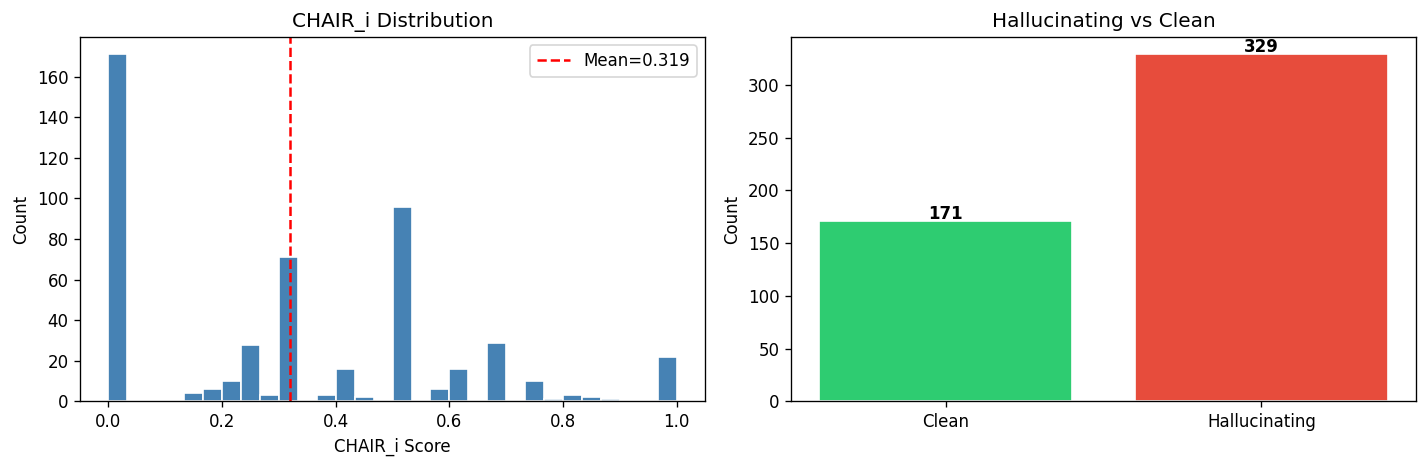

✅ Plot saved.


In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 120

valid = df[df['chair_i'] >= 0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(valid['chair_i'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(valid['chair_i'].mean(), color='red', ls='--',
                label=f"Mean={valid['chair_i'].mean():.3f}")
axes[0].set_xlabel('CHAIR_i Score'); axes[0].set_ylabel('Count')
axes[0].set_title('CHAIR_i Distribution'); axes[0].legend()

counts = valid['is_hallucinating'].value_counts()
bars = axes[1].bar(['Clean', 'Hallucinating'],
                   [counts.get(False,0), counts.get(True,0)],
                   color=['#2ecc71','#e74c3c'], edgecolor='white')
for b, v in zip(bars, [counts.get(False,0), counts.get(True,0)]):
    axes[1].text(b.get_x()+b.get_width()/2, v+2, str(v), ha='center', fontweight='bold')
axes[1].set_ylabel('Count'); axes[1].set_title('Hallucinating vs Clean')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chair_distribution.png", bbox_inches='tight')
plt.show()
print("✅ Plot saved.")
